In [10]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/yapo_clean.csv')

In [12]:
# ==============================================================================
# 1. PREPARACIÓN DE LA VARIABLE BINARIA (TREATMENT)
# ==============================================================================
# Aseguramos el formato minúscula y sin espacios extra para evitar errores
df['tipo_vendedor'] = df['tipo_vendedor'].astype(str).str.lower().str.strip()

# Creamos la variable binaria: 1 si es profesional/automotora, 0 si es particular
df['es_automotora'] = np.where(df['tipo_vendedor'] == 'profesional', 1, 0)

print(f"Distribución de la nueva variable binaria:\n{df['es_automotora'].value_counts(normalize=True)*100}\n")



Distribución de la nueva variable binaria:
es_automotora
0    69.685017
1    30.314983
Name: proportion, dtype: float64



In [ ]:

# ==============================================================================
# 2. FUNCIÓN DE AUDITORÍA DE POSITIVIDAD POR TEXTO
# ==============================================================================
def verificar_positividad_texto(df):
    df_clean = df.copy()
    
    # Rellenar nulos en la descripción
    df_clean['descripcion'] = df_clean['descripcion'].fillna('sin_descripcion').str.lower()
    
    # Lista básica de stop words en español para limpiar el ruido del texto
    stop_words_es = [
        'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 'un', 
        'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 'sus', 'le', 
        'ya', 'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 'muy', 'sin', 'sobre', 
        'también', 'me', 'hasta', 'hay', 'donde', 'quien', 'desde', 'todo', 'nos', 'durante', 
        'todos', 'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso', 'ante', 'ellos', 'e', 
        'esto', 'mí', 'antes', 'algunos', 'qué', 'unos', 'yo', 'otro', 'otras', 'otra', 'él', 
        'tanto', 'esa', 'estos', 'mucho', 'quienes', 'nada'
    ]
    
    # Vectorización: Extraemos las 300 palabras más frecuentes (excluyendo stop-words)
    print("Vectorizando textos...")
    tfidf = TfidfVectorizer(max_features=300, stop_words=stop_words_es)
    X_text = tfidf.fit_transform(df_clean['descripcion'])
    y = df_clean['es_automotora']
    
    # Dividir datos en entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)
    
    # Entrenar modelo
    print("Entrenando clasificador Random Forest...")
    clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    
    # Evaluar separación
    y_pred_proba = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"\n>>> ROC-AUC de separación por texto: {auc:.3f} <<<")
    if auc > 0.90:
        print("⚠️ ALERTA: El texto está separando casi perfectamente a los grupos. Habrá problemas de positividad.")
    elif auc < 0.85:
        print("✅ EXCELENTE: El texto captura señal pero mantiene solapamiento (overlap) saludable.")
    
    # Analizar palabras clave
    importances = clf.feature_importances_
    vocab = np.array(tfidf.get_feature_names_out())
    top_indices = np.argsort(importances)[::-1][:20]
    
    print("\nTop 20 palabras que más delatan a una automotora:")
    print("-" * 50)
    for word, imp in zip(vocab[top_indices], importances[top_indices]):
         print(f"{word.ljust(15)}: {imp:.4f}")

    # Gráfico de Propensity Score
    plt.figure(figsize=(10, 6))
    sns.histplot(y_pred_proba[y_test == 1], color='#1f77b4', label='Automotora (1)', kde=True, stat='density', alpha=0.5, bins=30)
    sns.histplot(y_pred_proba[y_test == 0], color='#d62728', label='Particular (0)', kde=True, stat='density', alpha=0.5, bins=30)
    plt.title('Distribución de Probabilidad Predicha (Propensity Score)\n¿Hay solapamiento entre automotoras y particulares?', fontsize=14)
    plt.xlabel('P(Automotora | Texto del Anuncio)', fontsize=12)
    plt.ylabel('Densidad', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 3. EJECUCIÓN
# ==============================================================================
verificar_positividad_texto(df)

Vectorizando textos (Iteración 2)...

>>> NUEVO ROC-AUC: 0.925 <<<

Nuevas Top 20 palabras predictoras:
--------------------------------------------------
transmisión    : 0.0516
mismo          : 0.0359
control        : 0.0330
contáctanos    : 0.0304
20             : 0.0281
vehículos      : 0.0256
agenda         : 0.0248
tarjeta        : 0.0245
visita         : 0.0239
papeles        : 0.0213
generalaire    : 0.0181
nuestro        : 0.0164
autos          : 0.0158
escríbenos     : 0.0150
contado        : 0.0150
compra         : 0.0148
equipamiento   : 0.0148
marca          : 0.0144
año            : 0.0141
ejecutivos     : 0.0138


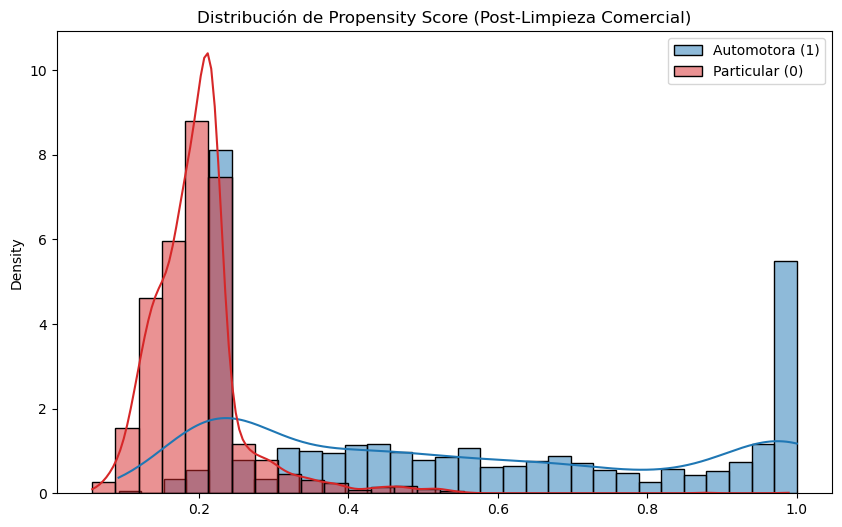

In [13]:
def verificar_positividad_texto_iteracion2(df):
    df_clean = df.copy()
    
    # 1. Corrección del artefacto: en lugar de 'sin_descripcion', dejamos vacío
    # para que el TF-IDF simplemente no extraiga tokens de ahí.
    df_clean['descripcion'] = df_clean['descripcion'].fillna('').str.lower()
    
    # 2. Stop words base + Palabras de Marketing detectadas
    stop_words_es = [
        'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 'un', 
        'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 'sus', 'le', 
        'ya', 'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 'muy', 'sin', 'sobre', 
        'también', 'me', 'hasta', 'hay', 'donde', 'quien', 'desde', 'todo', 'nos', 'durante', 
        'todos', 'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso', 'ante', 'ellos', 'e', 
        'esto', 'mí', 'antes', 'algunos', 'qué', 'unos', 'yo', 'otro', 'otras', 'otra', 'él', 
        'tanto', 'esa', 'estos', 'mucho', 'quienes', 'nada'
    ]
    
    # [NUEVO] Palabras "contaminantes" de modelo de negocio (marketing/pagos)
    stop_words_comerciales = [
        'tu', 'recibimos', 'pago', 'parte', 'hoy', 'crédito', 'color', 
        'financiamiento', 'automotriz', 'vende', 'tarjetas', 'pie', 'día', 
        'conversable', 'financiamientoprecio', 'nuestros', 'vendo', 'auto',
        'vehículo', 'whatsapp', 'fono', 'llamar', 'consulta', 'ofrecemos',
        'créditos', 'aprobación', 'llevatelo', 'cuotas', 'visítanos', 'contacto'
    ]
    
    stop_words_totales = stop_words_es + stop_words_comerciales
    
    print("Vectorizando textos (Iteración 2)...")
    tfidf = TfidfVectorizer(max_features=300, stop_words=stop_words_totales)
    X_text = tfidf.fit_transform(df_clean['descripcion'])
    y = df_clean['es_automotora']
    
    # Dividir y Entrenar
    X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)
    clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    
    # Evaluar
    y_pred_proba = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"\n>>> NUEVO ROC-AUC: {auc:.3f} <<<")
    
    # Analizar nuevas palabras clave
    importances = clf.feature_importances_
    vocab = np.array(tfidf.get_feature_names_out())
    top_indices = np.argsort(importances)[::-1][:20]
    
    print("\nNuevas Top 20 palabras predictoras:")
    print("-" * 50)
    for word, imp in zip(vocab[top_indices], importances[top_indices]):
         print(f"{word.ljust(15)}: {imp:.4f}")

    # Distribución
    plt.figure(figsize=(10, 6))
    sns.histplot(y_pred_proba[y_test == 1], color='#1f77b4', label='Automotora (1)', kde=True, stat='density', alpha=0.5, bins=30)
    sns.histplot(y_pred_proba[y_test == 0], color='#d62728', label='Particular (0)', kde=True, stat='density', alpha=0.5, bins=30)
    plt.title('Distribución de Propensity Score (Post-Limpieza Comercial)')
    plt.legend()
    plt.show()

verificar_positividad_texto_iteracion2(df)